In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Input,Dense,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array
from PIL import Image

2026-03-01 21:58:00.026013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772402280.390880      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772402280.491166      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772402281.337555      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772402281.337601      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772402281.337604      55 computation_placer.cc:177] computation placer alr

In [2]:
labels=[]
files_paths=[]
train='/kaggle/input/datasets/imrankhan77/nct-crc-he-100k/NCT-CRC-HE-100K'
folders=os.listdir(train)
for folder in folders:
    folder_path=os.path.join(train,folder)
    files=os.listdir(folder_path)
    for file in files:
        file_path=os.path.join(folder_path,file)
        labels.append(folder)
        files_paths.append(file_path)

df=pd.DataFrame({'files_paths':files_paths,'labels':labels})
df

train_df,valid_df=train_test_split(df,train_size=0.8,shuffle=True,random_state=42)

In [3]:
gen=ImageDataGenerator()
train_gen=gen.flow_from_dataframe(train_df,x_col="files_paths",y_col="labels",shuffle=True,
                                 class_mode="categorical",color_mode="rgb",
                                 target_size=(224,224),batch_size=16)

valid_gen=gen.flow_from_dataframe(valid_df,x_col="files_paths",y_col="labels",shuffle=True,
                                 class_mode="categorical",color_mode="rgb",
                                 target_size=(224,224),batch_size=16)

Found 80000 validated image filenames belonging to 9 classes.
Found 20000 validated image filenames belonging to 9 classes.


In [4]:
base_model=tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224,224,3),
)

model=Sequential([
    base_model,
    Flatten(),
    Dense(256,activation="relu"),
    Dense(128,activation="relu"),
    Dense(9,activation="softmax")
])

model.compile(optimizer=Adam(learning_rate=0.00001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

model.fit(train_gen,epochs=25)

model.evaluate(train_gen)
model.evaluate(valid_gen)

I0000 00:00:1772402651.400448      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/25


I0000 00:00:1772402687.356407     127 service.cc:152] XLA service 0x7a7240003820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772402687.356444     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772402692.953372     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/5000 ━━━━━━━━━━━━━━━━━━━━ 74:07:16 53s/step - accuracy: 0.0625 - loss: 3.1692

I0000 00:00:1772402711.686707     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 543s 98ms/step - accuracy: 0.8756 - loss: 0.3728
Epoch 2/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9833 - loss: 0.0492
Epoch 3/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 489s 98ms/step - accuracy: 0.9918 - loss: 0.0236
Epoch 4/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9940 - loss: 0.0183
Epoch 5/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9953 - loss: 0.0135
Epoch 6/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9962 - loss: 0.0104
Epoch 7/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9974 - loss: 0.0083
Epoch 8/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 492s 98ms/step - accuracy: 0.9981 - loss: 0.0062
Epoch 9/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 491s 98ms/step - accuracy: 0.9978 - loss: 0.0077
Epoch 10/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 490s 98ms/step - accuracy: 0.9983 - loss: 0.0051
Epoch 11/25
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 489s 98ms/step - accuracy: 0.9983 - loss: 0.0057
Epoch 12

[0.025906525552272797, 0.9947999715805054]

In [5]:
model.save('my_model.h5') 

In [6]:
my_model=load_model('/kaggle/working/my_model.h5')

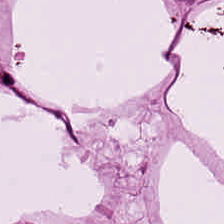

In [7]:
img='/kaggle/input/datasets/imrankhan77/nct-crc-he-100k/NCT-CRC-HE-100K/ADI/ADI-AAAMHQMK.tif'

img=Image.open(img)
img.resize((224,224))
img

In [8]:
img_arr=img_to_array(img)
img_arr.shape

(224, 224, 3)

In [9]:
img_array=tf.expand_dims(img_arr,0)
img_array.shape

TensorShape([1, 224, 224, 3])

In [10]:
my_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


array([[1.0000000e+00, 3.8886381e-15, 1.1220893e-15, 2.9664990e-24,
        6.8577483e-18, 3.9594745e-20, 7.8766994e-20, 8.3552855e-15,
        1.7200166e-18]], dtype=float32)

In [11]:
np.argmax(my_model.predict(img_array))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


np.int64(0)

In [12]:
train_gen.class_indices 

{'ADI': 0,
 'BACK': 1,
 'DEB': 2,
 'LYM': 3,
 'MUC': 4,
 'MUS': 5,
 'NORM': 6,
 'STR': 7,
 'TUM': 8}